# DSCI 633 Project
### Predicting Readmittance within 30 Days for Hospitalized Diabetes Patients  
*Michael Eaton, Rochester Institute of Technology — Fall 2025*

In [4]:
from shared_util.dataio import load_csv
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = load_csv('metrics')

In [7]:
df.head()

,model,data,threshold notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,TN,TP,FP,FN
id,,,,,,,,,,,,,,,
0,rf,train,base,under_sample,NaN,NaN,0.607229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,rf,train,base,SMOTE,NaN,NaN,0.504570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,rf,validate,base,under_sample,tuned_best_roc_auc,NaN,0.669986,0.631344,0.176897,0.615972,0.274859,8430.0,1049.0,4881.0,654.0
0,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,NaN,0.660745,0.546720,0.157859,0.690728,0.256987,7032.0,1177.0,6279.0,527.0
0,sgd,train,base,under_sample,NaN,first pass,0.574179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


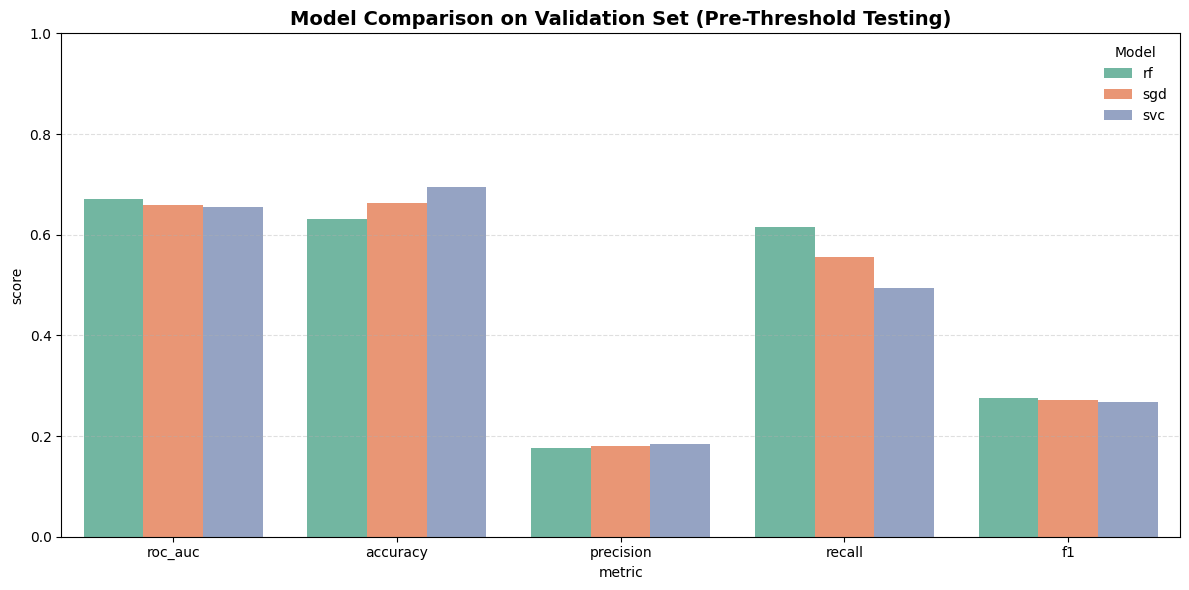

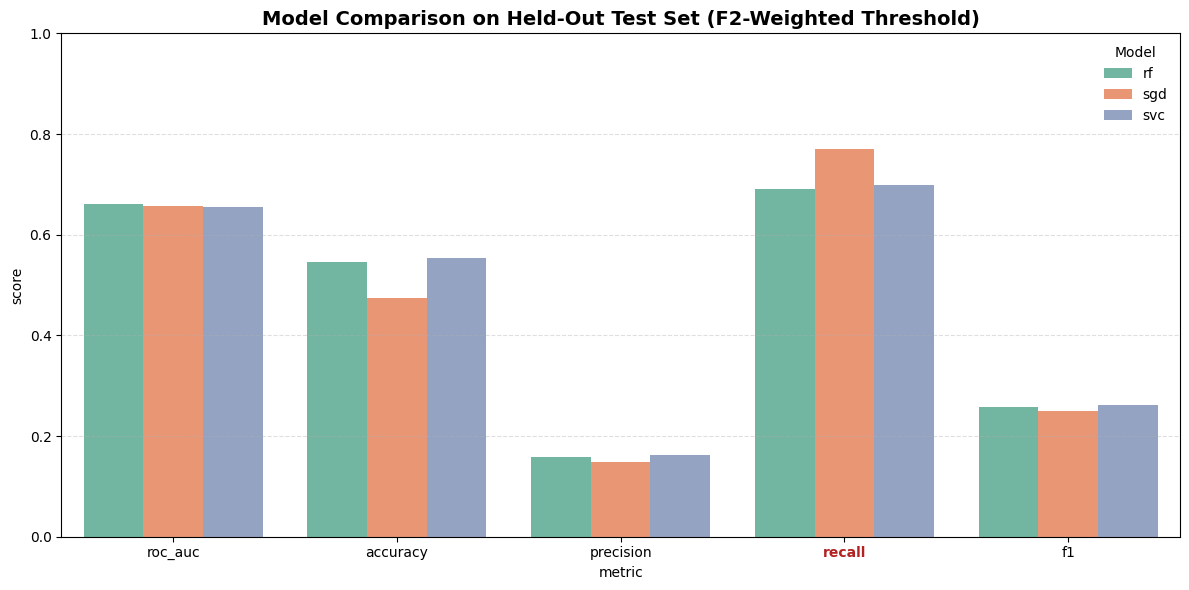

In [11]:
# numeric metrics
metrics = ["roc_auc", "accuracy", "precision", "recall", "f1"]

# ensure model column sorted nicely for consistent colors
df["model"] = df["model"].astype("category")
model_order = sorted(df["model"].unique())
palette = sns.color_palette("Set2", len(model_order))

# melt for plotting
melted = df.melt(
    id_vars=["model", "data"],
    value_vars=metrics,
    var_name="metric",
    value_name="score"
)

# helper to make consistent chart layout
def plot_metrics(subset, title, emphasize=None):
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=subset,
        x="metric", y="score",
        hue="model",
        palette=palette,
        errorbar=None
    )
    plt.ylim(0, 1)
    plt.title(title, fontsize=14, weight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    if emphasize:
        plt.axhline(0, color="none") 
        # slightly bold recall bars
        bars = plt.gca().patches
        for b in bars:
            if b.get_x() < 0:  #type: ignore
                continue
        # recolor recall tick label
        xticks = plt.gca().get_xticklabels()
        for t in xticks:
            if t.get_text().lower() == emphasize.lower():
                t.set_weight("bold") #type: ignore
                t.set_color("#b22222")
    plt.legend(title="Model", frameon=False)
    plt.tight_layout()
    plt.show()


# --- Plot 1: Validation (pre-threshold) ---
validate_df = melted[melted["data"] == "validate"]
plot_metrics(validate_df,
             "Model Comparison on Validation Set (Pre-Threshold Testing)")

# --- Plot 2: Test (F2-weighted, recall-focused) ---
test_df = melted[melted["data"] == "test"]
plot_metrics(test_df,
             "Model Comparison on Held-Out Test Set (F2-Weighted Threshold)",
             emphasize="recall")